In [6]:
%load_ext autoreload
%autoreload 2

import featuregraph as fg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
subject_id = 1
sampling_rate_hz = 125
smooth_window = 100
eps = 1e-12

df = fg.datasets.bidmc(subject=subject_id).copy()

from scipy.signal import find_peaks

# Detect peak locations.
peak_indices, peak_properties = find_peaks(df["respiration"].to_numpy())

# Mark peaks in the original DataFrame.
df['scipy_peak'] = False
df.loc[df.index[peak_indices], "scipy_peak"] = True

# Construct the respiratory envelope.
df['respiration_smooth'] = (
    df['respiration']
    .rolling(smooth_window, min_periods=smooth_window, center=True)
    .median()
    .rolling(smooth_window, min_periods=smooth_window, center=True)
    .mean()
)

df['respiration_minus_smoothing'] = df['respiration'] - df['respiration_smooth']

# Preserve the signed change.
df['respiration_change'] = (
    df['respiration_smooth'].diff()
)

df['respiration_change_unsmoothed'] = (
    df['respiration_minus_smoothing'].diff()
)

# A sample is valid for state assignment only when both the envelope
# and its preceding difference are defined.
df['respiration_smooth_valid'] = (
    df['respiration_smooth'].notna()
    & df['respiration_change'].notna()
)

valid = df['respiration_smooth_valid']

# Mutually exclusive directional states.
df['respiration_rising'] = (
    valid
    & df['respiration_change'].gt(eps)
)

df['respiration_rising_unsmoothed'] = (
    valid
    & df['respiration_change_unsmoothed'].gt(eps)
)

df['respiration_falling'] = (
    valid
    & df['respiration_change'].lt(-eps)
)

df['respiration_inactive'] = (
    valid
    & df['respiration_change'].abs().le(eps)
)

# Initialize events as False everywhere, including invalid edge samples.
df['enter_respiration_rising'] = False
df['exit_respiration_rising'] = False

# Calculate events only within the valid constructed interval.
df.loc[valid, 'enter_respiration_rising'] = (
    df.loc[valid, 'respiration_rising']
    .astype(int)
    .diff()
    .eq(1)
)

df.loc[valid, 'exit_respiration_rising'] = (
    df.loc[valid, 'respiration_rising']
    .astype(int)
    .diff()
    .eq(-1)
)

# Assign identity only after the final event columns have been constructed.
df['exit_respiration_rising_id'] = (
    df['exit_respiration_rising']
    .astype(int)
    .cumsum()
)

df['exit_respiration_rising_sig_diff'] = df['respiration_rising_unsmoothed'].astype(int).diff().eq(-1)
df['sig_diff'] = df['respiration_minus_smoothing']

(<Figure size 1600x660 with 3 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_smooth'>,
        <Axes: xlabel='Time', ylabel='exit_respiration_rising'>],
       dtype=object))

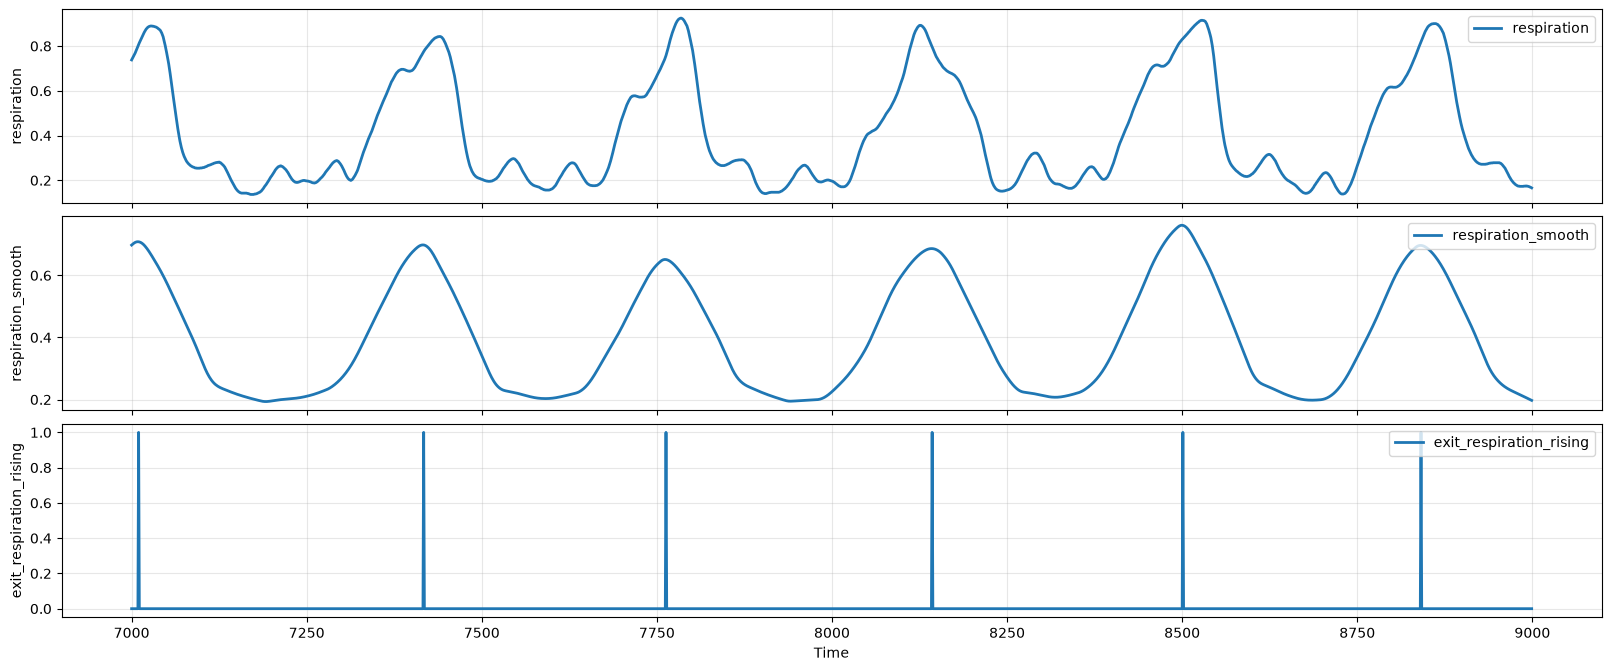

In [8]:
fg.plot(df[7000:9000], [['respiration'],
                              ['respiration_smooth'],
                              # ['sig_diff'],
                              ['exit_respiration_rising'],
                            #   ['scipy_peak'],
                              # ['ecg_ii', 'ecg_v'],
                             ]
)

In [9]:
summarydf = df.groupby('exit_respiration_rising_id').agg(
    start_time=('exit_respiration_rising', 'idxmax'),
    end_time=('exit_respiration_rising', 'idxmin'),
)       

In [10]:
summarydf

,start_time,end_time
exit_respiration_rising_id,,
0,0,0
1,179,180
2,460,461
3,736,737
4,1027,1028
...,...,...
167,58345,58346
168,58707,58708
169,59074,59075
